# B0 up close — real embeddings vs the losses

Load the trained **B0** model (distance-CL + SEL-independent), embed a small curated batch of seen
images + their per-rank texts, and inspect where they land **relative to what each loss optimizes**:

- **CL** (distance): image ↔ its *cumulative* species text. Positives = same full-string; negatives =
  every other species (family structure ignored, `cl_mask=none`).
- **SEL-intra**: *independent* per-rank cones nest (order ⊃ family ⊃ genus ⊃ species).
- **SEL-inter**: image inside its *independent* species cone.

Goal: see the disjoint-subspace concretely (CL target ≠ SEL target) on real data.

In [1]:
import sys; sys.path.insert(0, "/home/daniela/mine/hyperbolic-plankton/src")
import numpy as np, torch
import matplotlib.pyplot as plt
from hyperbolic_plankton import lorentz as L
from hyperbolic_plankton.bioscan import BioscanHDF5Dataset, BIOSCAN_RANKS
from hyperbolic_plankton.lora import apply_lora
from hyperbolic_plankton.model import HyperbolicCLIP
from hyperbolic_plankton.train import TaxonomyCollator

device = "cuda" if torch.cuda.is_available() else "cpu"
CKPT = "/scratch/daniela/hyperbolic_plankton_ckpts/bioscan_B0_baseline_r64_v4__xqmskk7s/bioscan_B0_baseline_r64_v4_best.pt"
HDF5 = "/scratch/daniela/bioscan1m/data/BIOSCAN_1M/split_data/BioScan_data_in_splits.hdf5"

## 1. Load B0

In [2]:
sd = torch.load(CKPT, map_location="cpu"); a = sd.get("args", {}); a = a if isinstance(a,dict) else vars(a)
model = HyperbolicCLIP(backbone=a.get("backbone","clip"))
model = apply_lora(model, r=a.get("lora_r",64), alpha=a.get("lora_alpha") or a.get("lora_r",64),
                   adapt_visual_blocks=a.get("lora_visual_blocks",12), adapt_text_blocks=a.get("lora_text_blocks",12))
model.load_state_dict(sd.get("model", sd), strict=False); model.to(device).eval()
curv = model.curvature
print(f"B0 loaded. curv={curv.item():.4f}  sel_text={a.get('sel_text')}  contrastive={a.get('contrastive')} "
      f"lambda_cl={a.get('lambda_cl')} lambda_sel={a.get('lambda_sel')}")

B0 loaded. curv=0.8512  sel_text=independent  contrastive=distance lambda_cl=1.0 lambda_sel=1.0


## 2. Curated batch: a few species with shared structure

Pick images spanning related + unrelated lineages so positives/negatives are meaningful:
some same-family (Gelechiidae), one different-family — so CL negatives and SEL pos/neg both have content.

In [3]:
ds = BioscanHDF5Dataset(HDF5, "test_seen")
# grab a handful of DISTINCT species, a few sharing family, with 2 images each where possible
want = []   # list of dataset indices
by_full = {}
for i in range(len(ds)):
    full = ds[i]["taxonomy"]["full"]
    by_full.setdefault(full, []).append(i)
# choose 4 species (2 images each) from Gelechiidae + 1 from another family
chosen_species = []
for full, idxs in by_full.items():
    if len(idxs) >= 2 and "Gelechiidae" in full and len(chosen_species) < 4:
        chosen_species.append(idxs[:2])
for full, idxs in by_full.items():
    if len(idxs) >= 2 and "Gelechiidae" not in full and "Lepidoptera" in full and len(chosen_species) < 5:
        chosen_species.append(idxs[:2]); break
want = [i for pair in chosen_species for i in pair]
items = [ds[i] for i in want]
pix, tb, _ = TaxonomyCollator(model.preprocess, ranks=BIOSCAN_RANKS)(items)
for k,it in enumerate(items):
    t=it["taxonomy"]; print(f"img{k}: {t['family_indep']:>16} / {t['genus_indep']:>14} / {t['species_indep']}")

img0:      Gelechiidae /     Dichomeris / Dichomeris santarosensis
img1:      Gelechiidae /     Dichomeris / Dichomeris santarosensis
img2:      Gelechiidae /   geleBioLep01 / geleBioLep01 BioLep440
img3:      Gelechiidae /   geleBioLep01 / geleBioLep01 BioLep440
img4:      Gelechiidae /          Sinoe / Sinoe BioLep2857
img5:      Gelechiidae /          Sinoe / Sinoe BioLep2857
img6:      Gelechiidae /       Telphusa / Telphusa BioLep476
img7:      Gelechiidae /       Telphusa / Telphusa BioLep476
img8:  Cosmopterigidae / cosmoMalaise01 / cosmoMalaise01 MalaiseMetz1051
img9:  Cosmopterigidae / cosmoMalaise01 / cosmoMalaise01 MalaiseMetz1051


## 3. Embed images + texts (cumulative for CL/eval, independent for SEL)

In [4]:
with torch.no_grad():
    img = model.encode_image(pix.to(device))                       # [N,D] image embeddings
    cum = model.encode_taxonomy(tb)                                # cumulative per-rank (CL target + classifier)
    indep = model.encode_taxonomy(tb, indep=True)                  # independent per-rank (SEL)
N = img.shape[0]
print("image radius:", L.distance_from_origin(img, curv).detach().cpu().numpy().round(3))
print("cumul species radius:", L.distance_from_origin(cum["species"], curv).detach().cpu().numpy().round(3))
print("indep species radius:", L.distance_from_origin(indep["species"], curv).detach().cpu().numpy().round(3))
print("indep order  radius:", L.distance_from_origin(indep["order"], curv).detach().cpu().numpy().round(3))

image radius: [1.106 1.226 1.296 1.249 1.124 1.083 1.285 1.209 1.121 1.137]
cumul species radius: [0.937 0.937 1.194 1.194 1.033 1.033 0.994 0.994 1.    1.   ]
indep species radius: [0.205 0.205 0.198 0.198 0.2   0.2   0.199 0.199 0.204 0.204]
indep order  radius: [0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15]


## 4. CL view: image ↔ cumulative-species distance matrix

Diagonal = positive (image to its OWN species text). Off-diagonal = negatives (incl. same-family).
A good CL geometry: diagonal is the row-minimum (image closest to its own species).

In [5]:
# (self-contained) unique-species index map for classification
uniq, fi, _seen = [], [], set()
for _k, _it in enumerate(items):
    _f = _it["taxonomy"]["full"]
    if _f not in _seen: _seen.add(_f); uniq.append(_f); fi.append(_k)
true = [uniq.index(_it["taxonomy"]["full"]) for _it in items]
N = len(items)

Psp = cum["species"][fi]
unames = [items[k]["taxonomy"]["species_indep"][:12] for k in fi]
Dcl = L.pairwise_dist(img, Psp, curv).detach().cpu().numpy()
print("image -> UNIQUE-species DISTANCE (rows=image, cols=unique species); * = row min")
print("           " + " ".join(f"{n[:9]:>10}" for n in unames))
for i in range(N):
    row=Dcl[i]; mn=row.argmin()
    cells_=" ".join((f"{v:9.3f}"+("*" if j==mn else " ")) for j,v in enumerate(row))
    ok = "OK" if mn==true[i] else f"MISCLASS->{unames[mn][:8]}"
    print(f"{unames[true[i]][:9]:>10} {cells_}   {ok}")
print(f"\nbatch nearest-species acc = {np.mean([Dcl[i].argmin()==true[i] for i in range(N)]):.2f}")

image -> UNIQUE-species DISTANCE (rows=image, cols=unique species); * = row min
            Dichomeri  geleBioLe  Sinoe Bio  Telphusa   cosmoMala
 Dichomeri     0.441*     0.982      1.322      0.950      1.761    OK
 Dichomeri     0.617*     1.019      1.554      1.005      1.874    OK
 geleBioLe     1.258      0.662*     1.289      0.880      1.392    OK
 geleBioLe     1.014      0.741      1.278      0.487*     1.583    MISCLASS->Telphusa
 Sinoe Bio     1.341      1.076      0.493*     1.278      1.258    OK
 Sinoe Bio     1.175      1.009      0.547*     1.219      1.364    OK
 Telphusa      1.105      0.502*     1.305      0.688      1.495    MISCLASS->geleBioL
 Telphusa      0.954      0.639      1.292      0.497*     1.500    OK
 cosmoMala     1.559      1.337      1.374      1.325      0.683*   OK
 cosmoMala     1.534      1.369      1.414      1.329      0.733*   OK

batch nearest-species acc = 0.80


## 5. SEL-inter view: is each image inside its INDEPENDENT species cone?

`oxy_angle(species_indep, image)` vs `half_aperture(species_indep)`. Inside iff angle ≤ aperture.
Compare to where CL actually put the image (cumulative species).

In [6]:
# SEL-inter: is each image inside its INDEPENDENT species cone? compare to CL's cumulative target.
names = [it["taxonomy"]["species_indep"] for it in items]
ang = L.oxy_angle(indep["species"], img, curv).detach().cpu().numpy()
ap  = L.half_aperture(indep["species"], curv).detach().cpu().numpy()
d_cl  = L.pairwise_dist(img, cum["species"], curv).diagonal().detach().cpu().numpy()
d_sel = L.pairwise_dist(img, indep["species"], curv).diagonal().detach().cpu().numpy()
print(f"{'species':>14} {'oxy_ang':>8} {'aperture':>9} {'in_cone':>8} {'d(img,CUMUL_sp)':>15} {'d(img,INDEP_sp)':>15}")
for i in range(len(items)):
    print(f"{names[i][:14]:>14} {ang[i]:8.3f} {ap[i]:9.3f} {str(ang[i]<=ap[i]):>8} {d_cl[i]:15.3f} {d_sel[i]:15.3f}")

       species  oxy_ang  aperture  in_cone d(img,CUMUL_sp) d(img,INDEP_sp)
Dichomeris san    1.438     1.571     True           0.441           1.054
Dichomeris san    1.451     1.571     True           0.617           1.179
geleBioLep01 B    1.613     1.571    False           0.662           1.282
geleBioLep01 B    1.615     1.571    False           0.741           1.235
Sinoe BioLep28    1.492     1.571     True           0.493           1.085
Sinoe BioLep28    1.509     1.571     True           0.547           1.047
Telphusa BioLe    1.572     1.571    False           0.688           1.263
Telphusa BioLe    1.527     1.571     True           0.497           1.178
cosmoMalaise01    1.559     1.571     True           0.683           1.094
cosmoMalaise01    1.534     1.571     True           0.733           1.105


## 6. The disjoint subspace, visualised (HoroPCA-free 2D: radius vs angle-from-mean)

Plot every embedding's (radius, angular position) so we can see images sit near CUMULATIVE species
(CL works) but far from INDEPENDENT species (SEL's target), and where the independent rank cones sit.

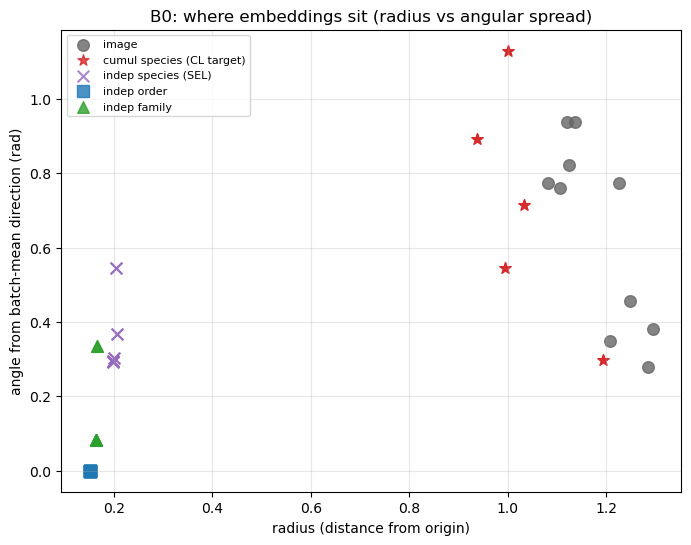

In [7]:
def radial_angular(X):
    r = L.distance_from_origin(X, curv).detach().cpu().numpy()
    # angle of the space-component direction relative to the batch mean direction (for a 2D readout)
    Xs = X.detach().cpu().numpy()
    mean_dir = Xs.mean(0); mean_dir /= (np.linalg.norm(mean_dir)+1e-9)
    cos = (Xs @ mean_dir) / (np.linalg.norm(Xs,axis=1)+1e-9)
    th = np.arccos(np.clip(cos,-1,1))
    return r, th
plt.figure(figsize=(8,6))
for label, X, m, c in [("image", img, "o", "0.4"),
                        ("cumul species (CL target)", cum["species"], "*", "tab:red"),
                        ("indep species (SEL)", indep["species"], "x", "tab:purple"),
                        ("indep order", indep["order"], "s", "tab:blue"),
                        ("indep family", indep["family"], "^", "tab:green")]:
    r, th = radial_angular(X)
    plt.scatter(r, th, marker=m, c=c, s=70, label=label, alpha=0.8)
plt.xlabel("radius (distance from origin)"); plt.ylabel("angle from batch-mean direction (rad)")
plt.title("B0: where embeddings sit (radius vs angular spread)"); plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.show()

---
# 7. Control: C4 = B0 with SEL REMOVED (lambda_sel=0)

C4 is identical to B0 (distance-CL, cumulative species target, cl_mask=none, r64) except **SEL is off**.
So C4 isolates *exactly what SEL does to B0's geometry*. Load C4, embed the SAME batch, compare.

In [8]:
C4_CKPT = "/scratch/daniela/hyperbolic_plankton_ckpts/bioscan_C4_clonly_r64_v4__ijgv7w6n/bioscan_C4_clonly_r64_v4_best.pt"
sd4 = torch.load(C4_CKPT, map_location="cpu"); a4 = sd4.get("args",{}); a4=a4 if isinstance(a4,dict) else vars(a4)
m4 = HyperbolicCLIP(backbone="clip")
m4 = apply_lora(m4, r=64, alpha=64, adapt_visual_blocks=12, adapt_text_blocks=12)
m4.load_state_dict(sd4.get("model", sd4), strict=False); m4.to(device).eval()
curv4 = m4.curvature
print(f"C4 loaded. curv={curv4.item():.4f}  lambda_sel={a4.get('lambda_sel')} (SEL OFF)")
with torch.no_grad():
    img4 = m4.encode_image(pix.to(device))
    cum4 = m4.encode_taxonomy(tb)
    indep4 = m4.encode_taxonomy(tb, indep=True)

C4 loaded. curv=0.8466  lambda_sel=0.0 (SEL OFF)


## 7a. Same-batch classification: B0 vs C4 (does SEL help or hurt these images?)

In [9]:
# (self-contained) unique-species index map for classification
uniq, fi, _seen = [], [], set()
for _k, _it in enumerate(items):
    _f = _it["taxonomy"]["full"]
    if _f not in _seen: _seen.add(_f); uniq.append(_f); fi.append(_k)
true = [uniq.index(_it["taxonomy"]["full"]) for _it in items]
N = len(items)

def batch_acc(image, cumemb, curv_):
    Psp = cumemb["species"][fi]
    D = L.pairwise_dist(image, Psp, curv_).detach().cpu().numpy()
    correct = [D[i].argmin()==true[i] for i in range(N)]
    dc = D[np.arange(N), true]; dd = D.copy(); dd[np.arange(N), true] = np.inf
    margin = dd.min(1) - dc
    return float(np.mean(correct)), correct, margin
for tag, image, cumemb, cv in [("B0 (with SEL)", img, cum, curv), ("C4 (no SEL) ", img4, cum4, curv4)]:
    acc, correct, margin = batch_acc(image, cumemb, cv)
    print(f"{tag}: acc={acc:.2f}  per-image margin={margin.round(3)}  correct={[bool(c) for c in correct]}")

B0 (with SEL): acc=0.80  per-image margin=[ 0.509  0.388  0.219 -0.254  0.583  0.461 -0.186  0.143  0.642  0.597]  correct=[True, True, True, False, True, True, False, True, True, True]
C4 (no SEL) : acc=0.80  per-image margin=[ 0.44   0.539  0.178 -0.061  0.566  0.345 -0.179  0.378  0.889  0.846]  correct=[True, True, True, False, True, True, False, True, True, True]


## 7b. Geometry comparison: where do images & species land with vs without SEL?

Key question: SEL shapes the INDEPENDENT text (collapsed in B0). Does removing it change where the
CUMULATIVE species (the classifier) and images sit? If B0≈C4 on cumulative geometry, SEL only moved
the (unused) independent subspace → confirms SEL is irrelevant to classification.

In [10]:
# (self-contained) unique-species index map for classification
uniq, fi, _seen = [], [], set()
for _k, _it in enumerate(items):
    _f = _it["taxonomy"]["full"]
    if _f not in _seen: _seen.add(_f); uniq.append(_f); fi.append(_k)
true = [uniq.index(_it["taxonomy"]["full"]) for _it in items]
N = len(items)

def summarize(tag, image, cumemb, indepemb, cv):
    ir = L.distance_from_origin(image, cv).detach().cpu().numpy()
    cr = L.distance_from_origin(cumemb["species"], cv).detach().cpu().numpy()
    isr = L.distance_from_origin(indepemb["species"], cv).detach().cpu().numpy()
    Psp = cumemb["species"][fi]
    PP = L.pairwise_dist(Psp, Psp, cv).detach().cpu().numpy(); np.fill_diagonal(PP, np.inf)
    nn = PP.min(1)
    print(f"{tag}: curv={cv.item():.3f}")
    print(f"   image radius           {ir.mean():.3f}")
    print(f"   CUMUL species radius   {cr.mean():.3f}   (classifier protos)")
    print(f"   INDEP species radius   {isr.mean():.3f}   (SEL target)")
    print(f"   species NN-sep (protos){nn.mean():.3f}   <- separation that drives classification")
summarize("B0 (SEL on) ", img, cum, indep, curv)
summarize("C4 (SEL off)", img4, cum4, indep4, curv4)

B0 (SEL on) : curv=0.851
   image radius           1.183
   CUMUL species radius   1.032   (classifier protos)
   INDEP species radius   0.201   (SEL target)
   species NN-sep (protos)0.918   <- separation that drives classification
C4 (SEL off): curv=0.847
   image radius           1.244
   CUMUL species radius   1.169   (classifier protos)
   INDEP species radius   0.844   (SEL target)
   species NN-sep (protos)1.067   <- separation that drives classification


---
# 8. Full 2×3 grid: {CL-only, CL+SEL, SEL-only} × {independent, cumulative}

Compare all loss combinations on the SAME batch. Isolates what CL vs SEL each contribute:

| | independent | cumulative |
|---|---|---|
| **CL only** | C4 | (= C4) |
| **CL + SEL** | B0 | C1 |
| **SEL only** | C3 | C2 |

Key column = **NN-sep** (nearest-neighbour species-prototype separation), the geometry that drives
classification. Self-contained: loads all 5, embeds this batch, prints the grid.

In [11]:
import glob, os
def load_cfg(tag):
    f = sorted(glob.glob(f"/scratch/daniela/hyperbolic_plankton_ckpts/{tag}__*/{tag}_best.pt"), key=os.path.getmtime)[-1]
    sd = torch.load(f, map_location="cpu"); aa = sd.get("args",{}); aa = aa if isinstance(aa,dict) else vars(aa)
    mm = HyperbolicCLIP(backbone="clip")
    mm = apply_lora(mm, r=64, alpha=64, adapt_visual_blocks=12, adapt_text_blocks=12)
    mm.load_state_dict(sd.get("model", sd), strict=False); mm.to(device).eval()
    return mm, mm.curvature, aa

GRID = [("B0  CL+SEL-indep", "bioscan_B0_baseline_r64_v4"),
        ("C4  CL-only",      "bioscan_C4_clonly_r64_v4"),
        ("C3  SEL-indep only","bioscan_C3_selonly_independent_r64_v4"),
        ("C1  CL+SEL-cumul", "bioscan_C1_seltext_cumulative_r64_v4"),
        ("C2  SEL-cumul only","bioscan_C2_selonly_cumulative_r64_v4")]

# self-contained unique-species map for this batch
uniq, fi, _s = [], [], set()
for _k, _it in enumerate(items):
    _f = _it["taxonomy"]["full"]
    if _f not in _s: _s.add(_f); uniq.append(_f); fi.append(_k)
true = [uniq.index(_it["taxonomy"]["full"]) for _it in items]; N = len(items)

In [12]:
# FULL test_seen (4878 images) so acc + geometry are trustworthy (not the 10-img batch).
full_ds = BioscanHDF5Dataset(HDF5, "test_seen")
full_items = [full_ds[i] for i in range(len(full_ds))]
fpix, ftb, _ = TaxonomyCollator(model.preprocess, ranks=BIOSCAN_RANKS)(full_items)  # preprocess is model-agnostic
fsp = ftb["species"]; funiq = sorted({s for s in fsp if s}); fidx = {s:i for i,s in enumerate(funiq)}
ftrue = np.array([fidx[s] for s in fsp])
print(f"full test_seen: {len(full_items)} images, {len(funiq)} species\n")

print(f"{'config':22} {'curv':6} {'acc':6} {'img_r':6} {'CUMsp_r':7} {'INDsp_r':7} {'NN-sep':7} {'INDord_r':8}")
print("-"*78)
for name, tag in GRID:
    m_, cv_, _ = load_cfg(tag)
    with torch.no_grad():
        im_  = torch.cat([m_.encode_image(fpix[i:i+256].to(device)) for i in range(0, len(full_items), 256)])
        cum_ = m_.encode_taxonomy(ftb)
        ind_ = m_.encode_taxonomy(ftb, indep=True)
    sp_emb = cum_["species"]
    P = torch.zeros(len(funiq), sp_emb.shape[1], device=device); cnt = torch.zeros(len(funiq), device=device)
    for i, s in enumerate(fsp):
        P[fidx[s]] += sp_emb[i]; cnt[fidx[s]] += 1
    P = P / cnt[:, None].clamp(min=1)
    pred = torch.cat([L.pairwise_dist(im_[i:i+256], P, cv_).argmin(1) for i in range(0, im_.shape[0], 256)])
    acc = (pred.cpu().numpy() == ftrue).mean()
    PP = L.pairwise_dist(P, P, cv_).detach().cpu().numpy(); np.fill_diagonal(PP, np.inf)
    rad = lambda X: L.distance_from_origin(X, cv_).detach().cpu().numpy().mean()
    print(f"{name:22} {cv_.item():6.3f} {acc:6.3f} {rad(im_):6.3f} {rad(cum_['species']):7.3f} "
          f"{rad(ind_['species']):7.3f} {PP.min(1).mean():7.3f} {rad(ind_['order']):8.3f}")
    del m_, im_, cum_, ind_, P; torch.cuda.empty_cache()

full test_seen: 4878 images, 916 species

config                 curv   acc    img_r  CUMsp_r INDsp_r NN-sep  INDord_r
------------------------------------------------------------------------------


B0  CL+SEL-indep        0.851  0.737  1.116   1.010   0.201   0.494    0.142


C4  CL-only             0.847  0.781  1.179   1.063   0.901   0.556    1.083


C3  SEL-indep only      0.976  0.318  0.292   0.102   0.147   0.018    0.057


C1  CL+SEL-cumul        1.272  0.600  1.880   1.005   0.255   0.201    0.097


C2  SEL-cumul only      0.991  0.499  0.274   0.130   0.106   0.041    0.060


**Reading the grid** (small-batch acc is coarse — geometry columns are robust):
- **NN-sep**: CL-only (C4) highest → CL+SEL-indep (B0) → CL+SEL-cumul (C1) → SEL-only (C2,C3 ≈ 0).
  CL *builds* separability; SEL *only reduces* it (least when disjoint/indep, most when it shares the
  classifier's cumulative text).
- **INDsp_r / INDord_r**: SEL collapses the independent text to the origin (~0.1–0.2); without SEL
  (C4) it floats at a normal radius (~0.8–1.1). That collapse is SEL's whole visible effect.
- **SEL-only (C3,C2)**: no CL → nothing anchors species → NN-sep ~0.03–0.11, everything near origin.